In [2]:
from utils import *
from genData import *
import time 
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from matplotlib.ticker import MultipleLocator
import numpy as np
from scipy.optimize import curve_fit

mplparams = {
    'text.usetex': True,  # use LaTeX for all text
    'axes.linewidth': 1,  # set axes linewidths to 0.5
    'axes.grid': False,  # add a grid
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 25
    #'font.serif': 'Computer Modern Roman'
}
matplotlib.rcParams.update(mplparams)
np.random.seed(111)
torch.manual_seed(111)

25-08-06 00:02:18.366 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


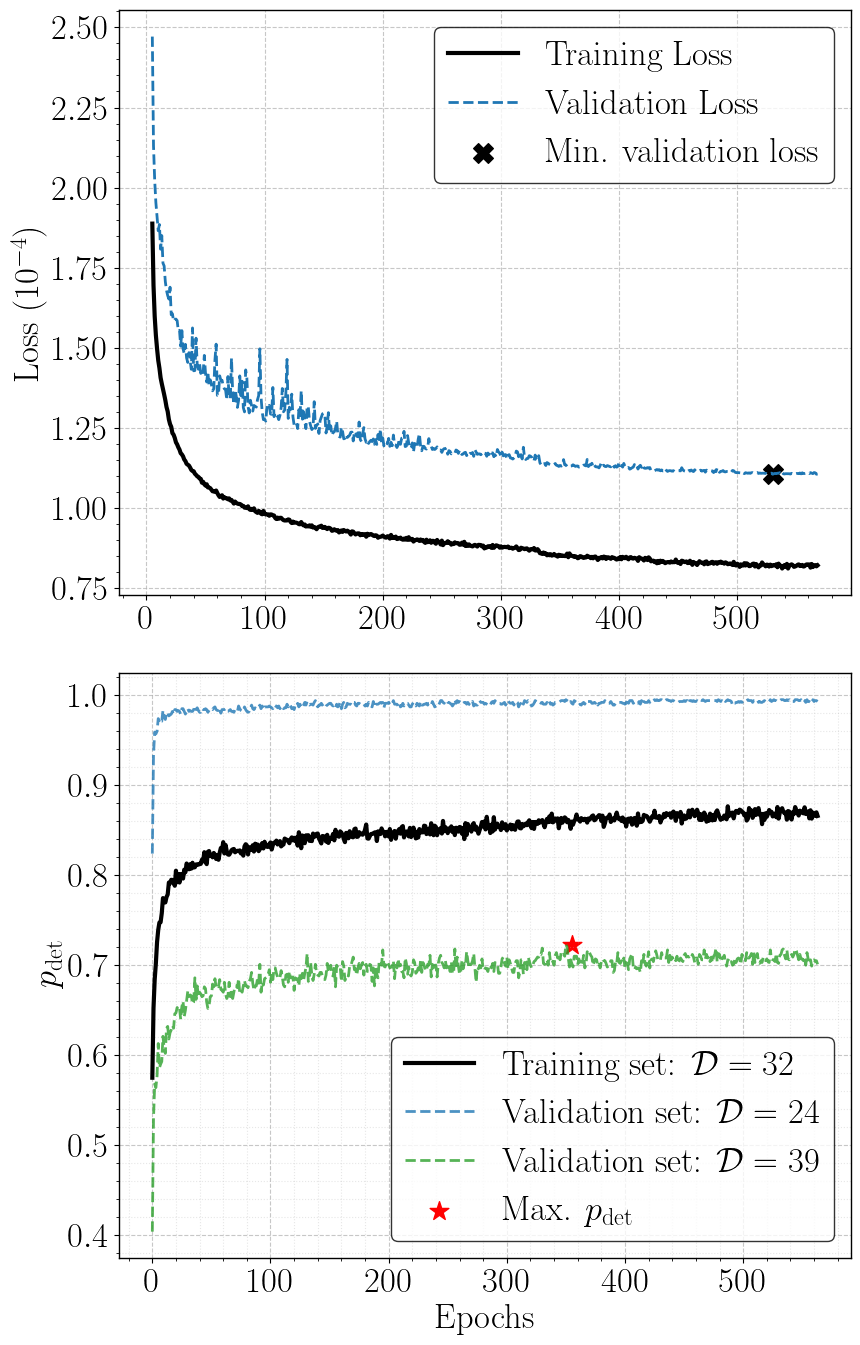

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load data (assuming data is available as per user input)
f0 = 20
version = f'H1L1_a1.0b1.0_{f0}Hz_D32-32_T10_Tsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'
data = np.load(f'/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/{f0}Hz/losses_{version}.npy', allow_pickle=True)

train_losses = data.item()['train_losses']
val_losses = data.item()['val_losses']
top_val_loss = data.item()['top_val_loss']
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

# Set up figure with two subplots, sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 14))

# --- Top Plot: Loss Curves ---
# Normalize losses for better visualization
ax1.plot(np.arange(len(train_losses))[5:], train_losses[5:]/1e-4 , label='Training Loss', color='black', lw=3, linestyle='-')
ax1.plot(np.arange(len(val_losses))[5:], val_losses[5:] /1e-4, label='Validation Loss', color='tab:blue', lw=2, linestyle='--')
idx = np.argmin(val_losses-top_val_loss)
ax1.scatter(idx, top_val_loss/1e-4, color='k', marker='X', label='Min. validation loss', s=200)


#ax1.set_yscale('log')
#ax1.set_ylim(7.5e-5, 1.9e-4)
ax1.set_ylabel('Loss ' +r'$(10^{-4})$')
#ax1.set_yticks([i for i in [1, 1.5, 2, 2.5]])  # Ticks every 5 weeks
#ax1.set_yticklabels([f'{i}' for i in [1, 1.5, 2, 2.5]])
ax1.tick_params(axis='both', which='major')
ax1.tick_params(axis='both', which='minor')
ax1.grid(True, which='major', linestyle='--', alpha=0.7)
ax1.minorticks_on()
ax1.legend(loc='best', frameon=True, edgecolor='k')

# --- Bottom Plot: p_det Curves ---
method = 'mean_sq'
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

# Plot training p_det curves
for i, key in enumerate(train_pdet[method].keys()):
    ax2.plot(
        np.arange(len(train_pdet[method][key][5:])),
        train_pdet[method][key][5:],
        label=f'Training set: $\\mathcal{{D}}={key}$',
        color='k',  # Slightly darker for training
        lw=3,
        linestyle='-'
    )

# Plot validation p_det curves
for i, key in enumerate(val_pdet[method].keys()):
    if key == 8 or key == 29.3:  # Skip key 8 as per original code
        continue
    ax2.plot(
        np.arange(len(val_pdet[method][key][5:])),
        val_pdet[method][key][5:],
        label=f'Validation set: $\\mathcal{{D}}={key}$',
        color=colors[i -1 % len(colors)],
        lw=2,
        linestyle='--',
        alpha=0.8
    )

# Highlight maximum p_det for key=39
idx = np.where(val_pdet[method][39] == max(val_pdet[method][39]))[0]
ax2.scatter(
    idx,
    np.ones(idx.size) * max(val_pdet[method][39]),
    color='red',
    marker='*',
    s=200,
    label='Max. $p_\\mathrm{det}$',
)

ax2.set_xlabel('Epochs')
ax2.set_ylabel('$p_\\mathrm{det}$')
ax2.tick_params(axis='both', which='major')
ax2.tick_params(axis='both', which='minor')
ax2.grid(True, which='major', linestyle='--', alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)
ax2.minorticks_on()
ax2.legend(loc='best', frameon=True, edgecolor='k')

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'../result/plots/combined_loss_pdet_{f0}Hz.pdf', dpi=300, bbox_inches='tight')